### Dynamic Rebalancing Strategy Backtest

This cell simulates a geometric mean-reversion (or dynamic rebalancing) trading strategy on historical `SOL/USDT` data.

**Key Components:**

* **Data Ingestion:** Efficiently extracts historical close prices and timestamps from a Parquet file using `duckdb` and `numpy`.
* **Execution Logic:** The algorithm anchors to a baseline equity `level` (100 USDT) and defines upper and lower bounds using a geometric `ratio`. When the position's equity crosses these bounds and subsequently reverts, the script executes a rebalancing trade to restore the baseline amount, realizing the Profit and Loss (PnL) while accounting for a trading `fee` (0.1%).
* **Mathematical Expectation:** The expected PnL of this strategy can be modeled as an infinite series:

$$E[PnL] = \sum_{n=1}^{\infty} \frac{ratio^n - 1}{2^{n+1}} (1 - fee) \cdot level + \sum_{n=1}^{\infty} \frac{ratio^{-n} - 1}{2^{n+1}} (1 + fee) \cdot level$$



*Note: For $ratio \ge 2$, the expectation becomes conditionally infinite as the payout growth outpaces the probability decay.*
* **Closed-Form Expectation:** For $1 < ratio < 2$, the infinite series converges to a closed-form equation:

$$E[PnL] = level \cdot (ratio - 1) \left[ \frac{1 - fee}{2 - ratio} - \frac{1 + fee}{2 \cdot ratio - 1} \right]$$



Using the script's parameters (`level = 100.0`, `ratio = 1.1`, `fee = 0.001`), the expected PnL per resolved cycle evaluates to **~2.76 USDT**.

100%|██████████| 2629439/2629439 [00:01<00:00, 2271282.52it/s]


Trades: 102
Wins: 49 (48.04%)
Average: +3.93 USDT
Gain: 400.56 USDT
Left: 107.43 USDT


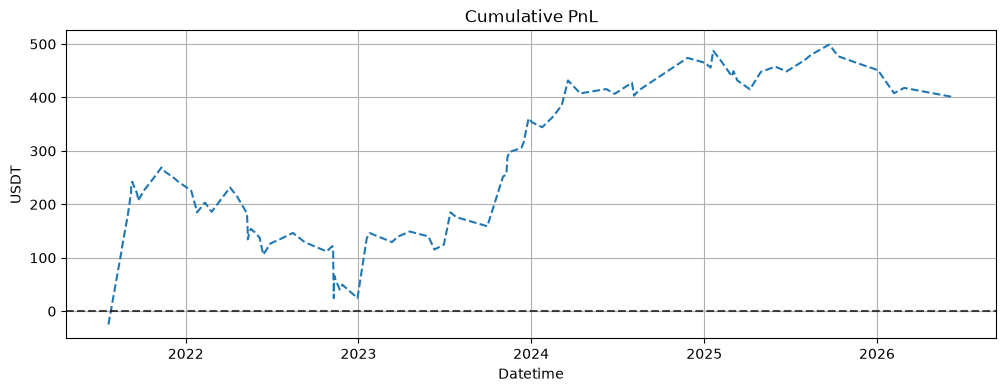

In [1]:
import duckdb
import numpy as np
import pandas as pd
from tqdm import tqdm
from matplotlib import pyplot as plt

cols = duckdb.read_parquet(
  '../data/processed/SOLUSDT_2021_2026.parquet'
).select(
  'open_time', 'close'
).fetchnumpy()

index = cols['open_time'] + np.timedelta64(1, 'm')
price = cols['close']
n_obs = len(index)

level = 100.0
ratio = 1.1
fee = 0.001

flag = 0
lb = level / ratio / ratio
ub = level * ratio * ratio
amt = level / price[0]

pnl_list = []
idx_list = []
for i, p in zip(tqdm(index[1:]), price[1:]):
  eq = amt * p
  if flag == -1:
    pending = eq >= ub
    if not pending and eq <= lb:
      lb /= ratio
      ub /= ratio
  elif flag == 1:
    pending = eq <= lb
    if not pending and eq >= ub:
      lb *= ratio
      ub *= ratio
  else:
    pending = False
    if eq <= lb:
      flag = -1
      ub = lb * ratio
      lb /= ratio
    elif eq >= ub:
      flag = 1
      lb = ub / ratio
      ub *= ratio
  if pending:
    pnl = eq - level
    amt -= pnl / p
    if pnl > 0.0: pnl *= 1.0 - fee
    else: pnl *= 1.0 + fee
    pnl_list.append(pnl)
    idx_list.append(i)
    lb = level / ratio / ratio
    ub = level * ratio * ratio
    flag = 0

res = pd.Series(pnl_list, idx_list)

n_trades = len(res)
n_wins = (res > 0.0).sum()
win_pct = n_wins / n_trades * 100.0 if n_trades else 0.0
gain = res.sum()
avg_pnl = gain / n_trades if n_trades else 0.0

print(f'Trades: {n_trades}')
print(f'Wins: {n_wins} ({win_pct:.2f}%)')
print(f'Average: {avg_pnl:+.2f} USDT')
print(f'Gain: {gain:.2f} USDT')
print(f'Left: {eq:.2f} USDT')

plt.figure(figsize=(12, 4))
plt.plot(res.cumsum(), ls='--')
plt.axhline(0.0, ls='--', color='black', alpha=0.7)
plt.xlabel('Datetime')
plt.ylabel('USDT')
plt.title('Cumulative PnL')
plt.grid()
plt.show()